# ICS 2207: Scientific Computing

# HydroSense-Kenya Capstone Project
# Level 5: Simulation and Optimization

## Introduction

Soil moisture simulation and irrigation optimization are important components of
the HydroSense-Kenya system because they allow prediction of future crop water
conditions and efficient use of available resources.

Numerical simulation methods are used to model how soil moisture changes over
time due to rainfall, evaporation, and irrigation. This notebook compares
different numerical approaches and applies uncertainty analysis to understand
possible water demand scenarios.

## Objectives

The objectives of this notebook are to:

- Simulate soil moisture changes over 30 days using the Euler method.
- Apply the Runge-Kutta method and compare simulation accuracy with Euler.
- Generate rainfall uncertainty scenarios using Monte Carlo simulation.
- Estimate water shortage probability and irrigation demand.
- Develop an irrigation schedule that maintains soil moisture above the minimum
  threshold.
- Analyse trade-offs between water conservation, crop stress, and energy use.

## Importing the reqired libraries and the Required Functions from src

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


sys.path.insert(0, str(PROJECT_ROOT / "src"))


from simulation import (
    soil_moisture_derivative,
    euler_simulation,
    rk4_simulation,
    monte_carlo_rainfall,
    monte_carlo_soil_simulation,
    shortage_and_overirrigation_probabilities
)

from optimization import *


print("Optimization functions imported successfully")
print("Simulation methods imported successfully")

Optimization functions imported successfully
Simulation methods imported successfully



## 2.Euler Method Simulation
### Soil Moisture Simulation Using Euler Method

The Euler method is a numerical technique used to approximate changes in a
system over time. In HydroSense-Kenya, it is used to estimate daily soil
moisture variation based on water inputs and losses.

The method updates soil moisture using:

Moisture(next) = Moisture(current) + change × time

This provides a simple approach for predicting moisture trends.

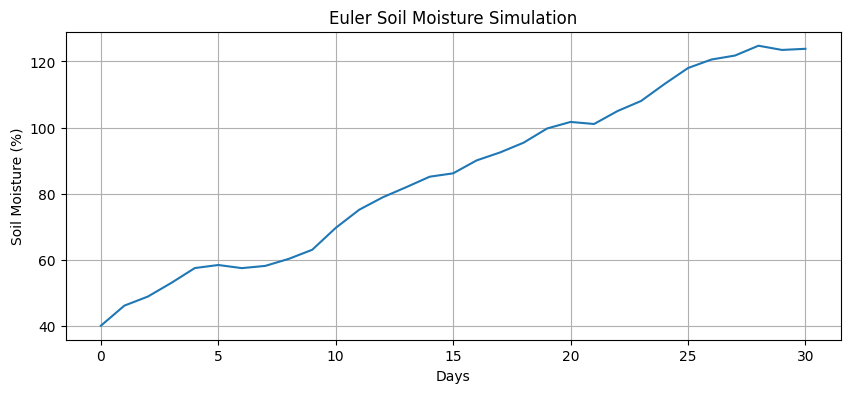

In [64]:
# Soil Moisture Simulation Using Euler Method

days = 30

initial_moisture = 40


# Generate rainfall data

rainfall = np.random.normal(
    5,
    2,
    days
)


# Irrigation input (initially zero)

irrigation = np.zeros(days)


# Evapotranspiration values

ET = np.ones(days) * 2


# Soil parameters

field_capacity = 100

k = 0.05



# Run Euler simulation

euler_results = euler_simulation(
    initial_moisture,
    rainfall,
    irrigation,
    ET,
    field_capacity,
    k
)



# Plot results

plt.figure(figsize=(10,4))

plt.plot(euler_results)

plt.title("Euler Soil Moisture Simulation")

plt.xlabel("Days")

plt.ylabel("Soil Moisture (%)")

plt.grid()

plt.show()

## Discussion

The Euler simulation provides an estimate of how soil moisture changes under
daily environmental conditions. Although computationally simple, the method may
introduce approximation errors because it assumes constant change during each
time step.

## 3.Runge-Kutta Method Simulation
### Runge-Kutta Simulation

The Runge-Kutta method improves numerical accuracy by evaluating the system at
multiple points within each time step.

Compared with Euler, it provides a more accurate representation of changing soil
moisture behaviour.

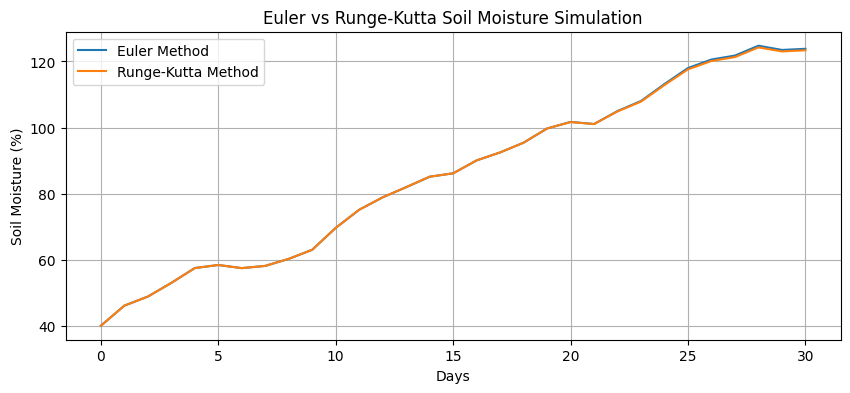

In [65]:
# Runge-Kutta Soil Moisture Simulation

rk_results = rk4_simulation(
    initial_moisture,
    rainfall,
    irrigation,
    ET,
    field_capacity,
    k
)


# Compare Euler and Runge-Kutta

plt.figure(figsize=(10,4))

plt.plot(euler_results, label="Euler Method")

plt.plot(rk_results, label="Runge-Kutta Method")


plt.title("Euler vs Runge-Kutta Soil Moisture Simulation")

plt.xlabel("Days")

plt.ylabel("Soil Moisture (%)")

plt.legend()

plt.grid()

plt.show()

## Discussion

The comparison shows how different numerical methods influence simulation
results. Runge-Kutta generally provides improved accuracy because it considers
multiple estimates during each update, making it suitable for environmental
systems with changing conditions.

## 4.Monte Carlo Uncertainty Analysis
### Monte Carlo Rainfall Uncertainty
Rainfall is naturally unpredictable. Monte Carlo simulation generates many
possible rainfall scenarios to understand possible future conditions.

This allows the system to estimate risks associated with drought and excessive
water supply.

Rainfall Scenario Shape:
(1000, 30)


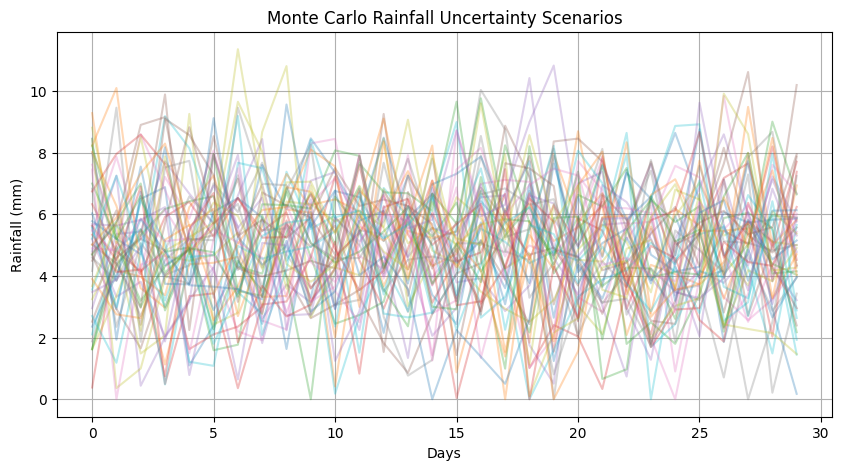

In [66]:
rainfall_scenarios = monte_carlo_rainfall(
    mean_rainfall=5,
    std_rainfall=2,
    n_days=30,
    n_scenarios=1000
)


print("Rainfall Scenario Shape:")
print(rainfall_scenarios.shape)
# Plot Monte Carlo rainfall scenarios

plt.figure(figsize=(10,5))

for i in range(50):   # Display first 50 scenarios
    plt.plot(
        rainfall_scenarios[i],
        alpha=0.3
    )


plt.title("Monte Carlo Rainfall Uncertainty Scenarios")

plt.xlabel("Days")

plt.ylabel("Rainfall (mm)")

plt.grid()

plt.show()

### Water Shortage and Irrigation Demand



### Monte Carlo soil moisture simulation
Generate rainfall scenarios

In [67]:
rainfall_scenarios = monte_carlo_rainfall(
    mean_rainfall=5,
    std_rainfall=2,
    n_days=30,
    n_scenarios=1000
)

print(rainfall_scenarios.shape)

(1000, 30)


Define irrigation and ET inputs

In [68]:
# Irrigation input (no scheduled irrigation yet)

irrigation = np.zeros(30)


# Evapotranspiration values

ET = np.ones(30) * 2

Run Monte Carlo soil moisture simulation

In [69]:
mc_soil_results = monte_carlo_soil_simulation(
    initial_moisture,
    rainfall_scenarios,
    irrigation,
    ET,
    field_capacity,
    k
)


print(mc_soil_results.shape)

(1000, 31)


calculate water shortage and over-irrigation

In [70]:
results = shortage_and_overirrigation_probabilities(
    mc_soil_results,
    min_threshold=30,
    field_capacity=100
)


print("Water Risk Analysis:")
print(results)

Water Risk Analysis:
{'p_shortage': 0.0, 'p_overirrigation': 0.999, 'expected_min_moisture': 39.94387739576177, 'worst_case_min_moisture': 39.66282321744834}


## Monte Carlo Water Risk Analysis Discussion

The Monte Carlo soil moisture simulation evaluates many possible rainfall
conditions and their effect on future soil moisture levels.

The analysis estimates the probability of water shortage when moisture falls
below the minimum crop requirement and identifies possible over-irrigation when
soil moisture exceeds field capacity.

These results support irrigation planning by balancing crop protection,
efficient water use, and energy requirements.

## 5.Irrigation Optimization
### Optimized Irrigation Schedule
The objective of irrigation optimization is to maintain soil moisture above the
minimum crop requirement while reducing unnecessary water usage.

An effective schedule balances:
- Crop water needs
- Available water resources
- Pump energy consumption

In [71]:
# Create irrigation schedule

irrigation_schedule = np.zeros(30)


# Apply irrigation when soil moisture goes below threshold

minimum_threshold = 30


for i in range(30):

    if euler_results[i] < minimum_threshold:
        irrigation_schedule[i] = 10


print("Optimized Irrigation Schedule:")
print(irrigation_schedule)

Optimized Irrigation Schedule:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [72]:

schedule = simulate_with_irrigation(
    S0=initial_moisture,
    R_series=rainfall,
    I_series=irrigation_schedule,
    ET_series=ET,
    field_capacity=field_capacity,
    k=k
)


schedule


array([ 40.        ,  46.08027517,  48.82395521,  52.96748509,
        57.45497861,  58.38058174,  57.43177533,  58.11049935,
        60.23704188,  62.99602999,  69.61804449,  75.10671732,
        78.86828323,  81.93460932,  85.10616929,  86.1326016 ,
        90.04333925,  92.45976803,  95.40846394,  99.70385423,
       101.68873331, 101.06251736, 104.98483297, 108.02603413,
       113.1684115 , 118.00353354, 120.58860264, 121.77674199,
       124.75758438, 123.48142387, 123.82319038])

optimized result:

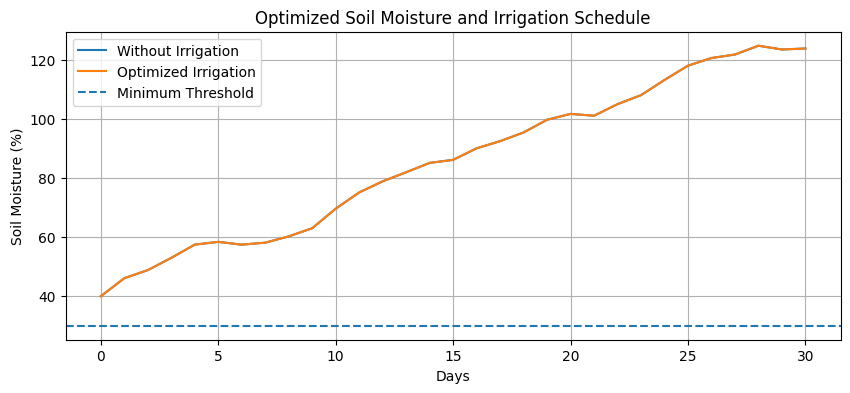

In [73]:
plt.figure(figsize=(10,4))

plt.plot(
    euler_results,
    label="Without Irrigation"
)

plt.plot(
    schedule,
    label="Optimized Irrigation"
)


plt.axhline(
    y=30,
    linestyle="--",
    label="Minimum Threshold"
)


plt.title("Optimized Soil Moisture and Irrigation Schedule")

plt.xlabel("Days")

plt.ylabel("Soil Moisture (%)")

plt.legend()

plt.grid()

plt.show()

## Discussion

The optimized schedule reduces excessive irrigation while preventing crop water
stress. The solution represents a balance between conservation and maintaining
healthy soil moisture conditions.

## 6.Trade-Off Analysis
### Trade-offs Between Water Conservation, Crop Stress and Energy Demand

Reducing irrigation saves water and decreases pump energy requirements.
However, excessive reduction may lower soil moisture below crop requirements,
causing crop stress.

Increasing irrigation improves moisture availability but increases water
consumption and energy costs.

The optimal strategy is therefore to apply only the required amount of water
while maintaining acceptable crop conditions.

# 7.Conclusion

- Soil moisture was simulated over 30 days using numerical methods.
- Euler and Runge-Kutta methods were compared to evaluate simulation behaviour.
- Monte Carlo simulation was used to analyse rainfall uncertainty.
- Water shortage probability and irrigation demand were estimated.
- An optimized irrigation schedule was developed to balance water efficiency and
  crop requirements.

The Level 5 simulation framework provides the foundation for intelligent
irrigation decisions by combining numerical modelling, uncertainty analysis,
and optimization techniques.